## Import libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix

## Load data

In [ ]:
# clinical_gex = pd.read_csv(
#     '../dataset/created/clinical_gex.csv',
#     index_col='Unnamed: 0',
#     low_memory=False
# )
# clinical_gex

,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,HL_Shi-35,male,61,IV,M1C,NaN,no,no,Hugo et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,HL_Shi-37,male,65,IV,M1A,NaN,no,no,Hugo et al.,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,HL_Shi-38,male,51,IV,M1C,NaN,no,no,Hugo et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,HL_Shi-43,female,41,IV,M1C,NaN,no,no,Hugo et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# from sklearn.model_selection import train_test_split

# y = clinical_gex['pfs_label']
# x = clinical_gex.copy()

# X_train, X_test, y_train, y_test = train_test_split(
#     x, y, stratify=y, test_size=0.2, random_state=42
# )

# print(f'Train: x shape {X_train.shape}')
# print(f'Test: x shape {X_test.shape}')

Train: x shape (107, 51486)
Test: x shape (27, 51486)


In [ ]:
# X_train.to_csv('../dataset/created/clinical_gex_train.csv')
# X_test.to_csv('../dataset/created/clinical_gex_test.csv')

In [19]:
clinical_gex = pd.read_csv(
    '../dataset/created/clinical_gex_corrected.csv',
    low_memory=False
)
clinical_gex.columns = clinical_gex.columns.str.strip()

groups = clinical_gex['source']

y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'index'], axis=1)

print(x.head())
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

      sex  age AJCC_stage M_stage       LDH immunotherapy_treatment  \
0    male   26         IV     M1B  elevated                      no   
1  female   58         IV     M1A    normal                      no   
2    male   45         IV     M1A    normal                      no   
3    male   48       IIIC     NaN    normal                      no   
4    male   33         IV     M1C    normal                      no   

  pre_MAPKi_treatment  cobimetinib  dabrafenib  trametinib  ...    ZWILCH  \
0                  no            0           0           0  ...  5.848178   
1                  no            0           0           0  ...  5.960990   
2                  no            0           0           0  ...  6.270929   
3                  no            1           0           0  ...  5.746751   
4                  no            1           0           0  ...  5.973635   

      ZWINT      ZXDA      ZXDB      ZXDC    ZYG11A    ZYG11B       ZYX  \
0  5.617357  4.337030  4.612033  5.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.2, random_state=42
)

print(f'Train: x shape {X_train.shape}')
print(f'Test: x shape {X_test.shape}')

Train: x shape (107, 17395)
Test: x shape (27, 17395)


In [15]:
# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH',
    'immunotherapy_treatment', 'pre_MAPKi_treatment'
]
clinical_numeric_col = ['age']

drug_braf_cols = [
    'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
    'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'
]

# Gene expression columns (everything else)
all_non_gex = (
    clinical_ordinal_col + clinical_categorical_cols +
    clinical_numeric_col + drug_braf_cols
)
gex_cols = [c for c in X_train.columns if c not in all_non_gex]

print(f"\nClinical features: {len(clinical_ordinal_col) + len(clinical_categorical_cols) + len(clinical_numeric_col)}")
print(f"Drug/BRAF dummies: {len(drug_braf_cols)}")
print(f"Gene expression features: {len(gex_cols)}")


Clinical features: 7
Drug/BRAF dummies: 10
Gene expression features: 17378


## Preprocessing pipeline

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough', drug_braf_cols)
    ],
    remainder='passthrough' # gene expressions
)

x_processed = clinical_preprocessor.fit_transform(X_train)
x_processed = pd.DataFrame(x_processed, columns=clinical_preprocessor.get_feature_names_out())
x_processed.columns = x_processed.columns.str.split('__').str[-1]
x_processed

,M_stage,sex_female,sex_male,AJCC_stage_IIIC,AJCC_stage_IV,LDH_elevated,LDH_normal,immunotherapy_treatment_no,pre_MAPKi_treatment_no,age,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,69.0,...,5.606326,5.736662,4.352403,4.650184,5.257030,4.127380,6.188420,7.734775,6.179496,6.002777
1,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,64.0,...,5.818967,5.624246,4.376068,4.614534,5.336755,4.133683,6.477861,7.294548,6.269186,6.200662
2,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,50.0,...,5.683684,5.412279,4.303943,4.717070,4.907961,4.151097,5.966762,6.760265,5.232001,5.581692
3,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,31.0,...,5.148437,5.327924,4.310204,5.022330,4.033290,4.627187,6.677532,6.581028,5.790019,6.486525
4,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,80.0,...,6.013582,5.750199,4.343170,4.598356,5.154309,4.119169,6.431703,7.547216,6.205301,6.003428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,43.0,...,5.629616,5.481977,4.448751,4.700733,5.693153,4.116850,6.353696,7.833018,6.501194,5.946785
103,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,44.0,...,5.611330,5.446941,4.355175,4.611476,5.151449,4.132684,6.373912,7.451293,5.969741,5.995065
104,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,33.0,...,4.881804,5.077598,4.375306,4.222889,5.460682,4.337838,5.629705,8.622429,6.373242,5.461180
105,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,61.0,...,5.911655,5.628828,4.342486,4.593738,5.192133,4.120223,6.486082,8.370269,6.294590,6.022659


In [17]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE

x = x_processed.copy()

new_pipe=Pipeline([
    ('threshold', VarianceThreshold(threshold=0.1)),
    ('seleckbest', SelectKBest(f_classif, k=500)),
    ('rfe', RFE(
        estimator=RandomForestClassifier(random_state=42), 
        step=1, 
        n_features_to_select=15
    ))
])

x = new_pipe.fit_transform(x, y)
x

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
# print("Selected genes:", x_rfe.columns.tolist())

In [ ]:
CV = 'skf'

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
    ))
])
    

def objective(trial):
        
    params = {
        'clf__C': trial.suggest_float('clf__C', 0.0001, 0.01, log=True), # smaller C higher penalty
        'clf__l1_ratio': trial.suggest_float('clf__l1_ratio', 0.0, 1.0),
        'clf__max_iter': trial.suggest_int('clf__max_iter', 100, 5000),
    }

    clf.set_params(**params)

    if CV == 'logo':
        scores = cross_val_score(clf, x, y, groups=groups, cv=logo, scoring='f1_macro', n_jobs=-1)
    elif CV == 'skf':
        scores = cross_val_score(clf, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best CV F1 macro:", study.best_value)

[I 2026-04-23 15:30:18,418] A new study created in memory with name: no-name-18f3f3b5-7a80-471b-a5e4-c491dc7040b9
[I 2026-04-23 15:30:18,561] Trial 0 finished with value: 0.08869599662438536 and parameters: {'clf__C': 0.0019584415381159828, 'clf__l1_ratio': 0.09468299630900678, 'clf__max_iter': 2193}. Best is trial 0 with value: 0.08869599662438536.
[I 2026-04-23 15:30:18,635] Trial 1 finished with value: 0.12445711659603165 and parameters: {'clf__C': 0.002073508121442906, 'clf__l1_ratio': 0.9695177195638064, 'clf__max_iter': 4301}. Best is trial 1 with value: 0.12445711659603165.
[I 2026-04-23 15:30:18,649] Trial 2 finished with value: 0.1715159401254434 and parameters: {'clf__C': 0.00023247345350534335, 'clf__l1_ratio': 0.3830474284448351, 'clf__max_iter': 672}. Best is trial 2 with value: 0.1715159401254434.
[I 2026-04-23 15:30:18,664] Trial 3 finished with value: 0.12445711659603165 and parameters: {'clf__C': 0.0020786994725070338, 'clf__l1_ratio': 0.5000099108001407, 'clf__max_ite

Best params: {'clf__C': 0.003273483957054355, 'clf__l1_ratio': 0.014883951584009255, 'clf__max_iter': 4174}
Best CV F1 macro: 0.7432875368718742


## Run models

Test ROC-AUC (OVO) : nan ± nan
Test Macro F1      : 0.743 ± 0.162
Train ROC-AUC (OVO): 0.908 ± 0.027
Train Macro F1     : 0.795 ± 0.026


              precision    recall  f1-score   support

  Short resp       0.78      0.87      0.82        70
Intermediate       0.78      0.70      0.74        30
   Long resp       0.76      0.65      0.70        34

    accuracy                           0.78       134
   macro avg       0.77      0.74      0.75       134
weighted avg       0.78      0.78      0.77       134



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
   

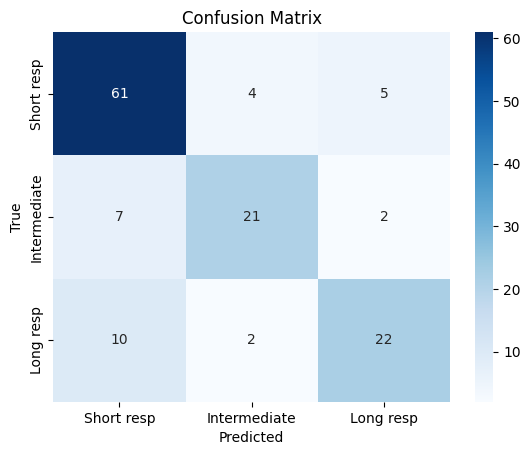

In [ ]:
clf.set_params(**study.best_params)

clf.fit(X_train, y_train)       # Train LR
y_pred = clf.predict(X_test)    # Validate

print("\n")
print(classification_report(
    y_test, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Explanability

### SHAP values

In [ ]:
import shap
shap.initjs()

model = clf.fit(x, y)

if CLASSIFIER == 'lr':
    x_shap = model.named_steps['scaler'].transform(x)
    x_shap = pd.DataFrame(x_shap, columns=x.columns)
    explainer = shap.LinearExplainer(clf.named_steps['clf'], x_shap)

elif CLASSIFIER == 'xgboost':
    x_shap = pd.DataFrame(x, columns=x.columns)
    explainer = shap.TreeExplainer(model, x_shap)
    
shap_values = explainer(x_shap)
np.shape(shap_values.values)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

### Waterfall plot

In [ ]:
OBS = 0
CLASS = 0
sv1 = shap_values[OBS, :, CLASS]      

predicted_class = int(model.predict(x)[OBS])
print(f'Predicted class of observation {OBS}, class {CLASS}: {predicted_class}')

Predicted class of observation 0, class 0: 0


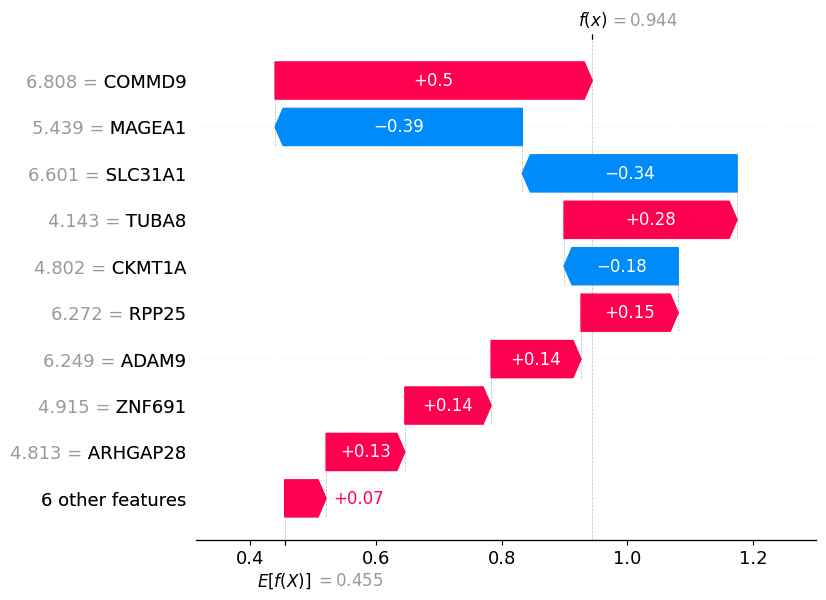

In [ ]:
shap.plots.waterfall(sv1)

### Force plot

In [ ]:
shap.plots.force(sv1)

### Stacked force plot

In [ ]:
sv_all = shap_values[:, :, CLASS]     

shap.plots.force(sv_all)


### Absolute mean SHAP

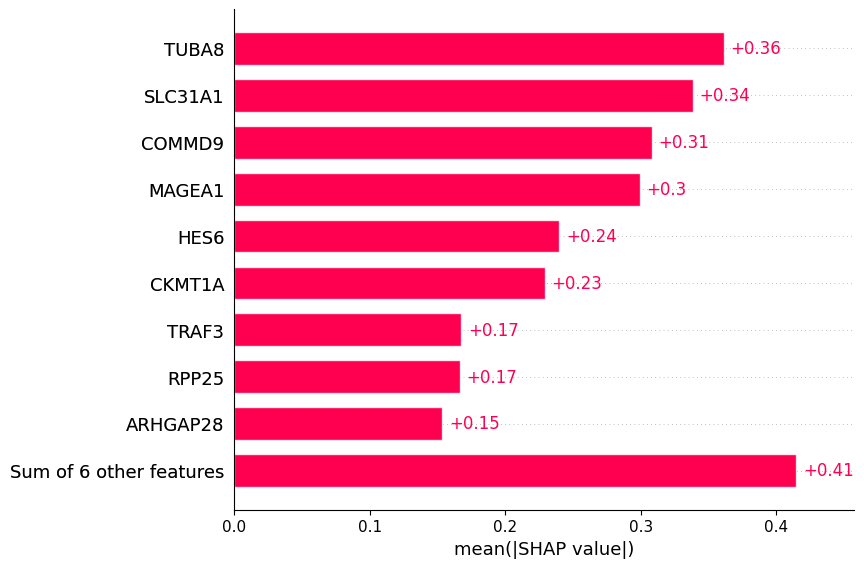

In [ ]:
shap.plots.bar(sv_all)

### Beeswarm plot

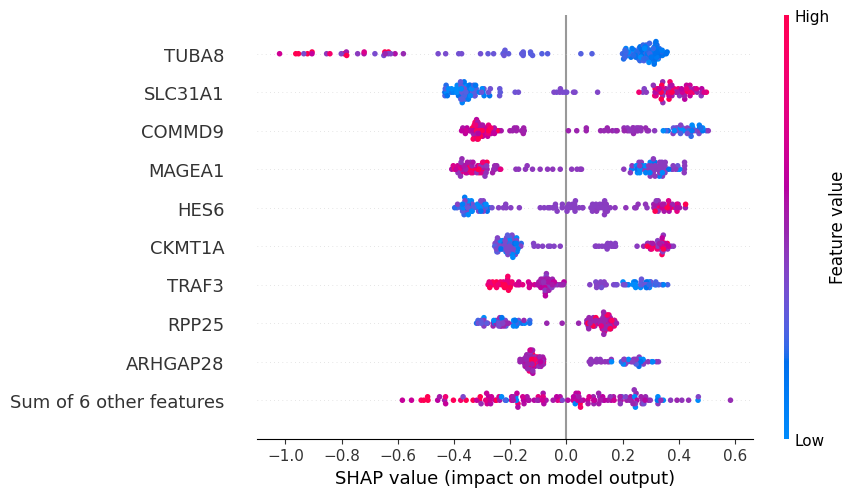

In [ ]:
shap.plots.beeswarm(sv_all)

### Dependence plots

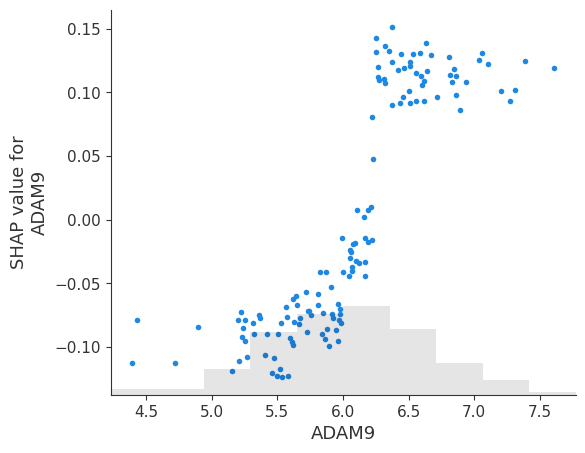

In [ ]:
shap.plots.scatter(sv_all[:, 'ADAM9'])

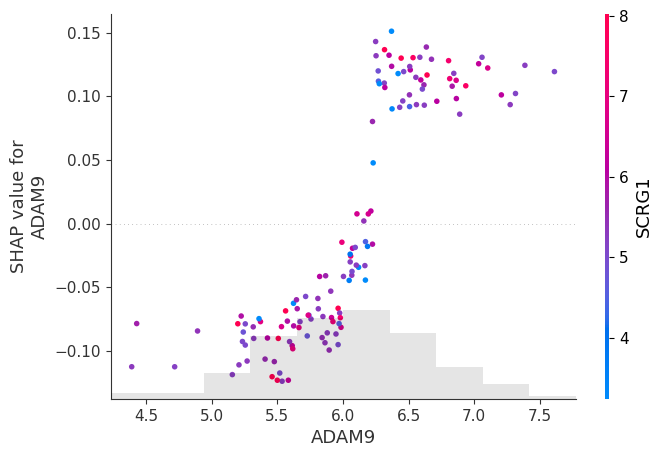

In [ ]:
shap.plots.scatter(
    shap_values=sv_all[:, 'ADAM9'],
    color=sv_all[:, 'SCRG1']
)

### Heatmap plot

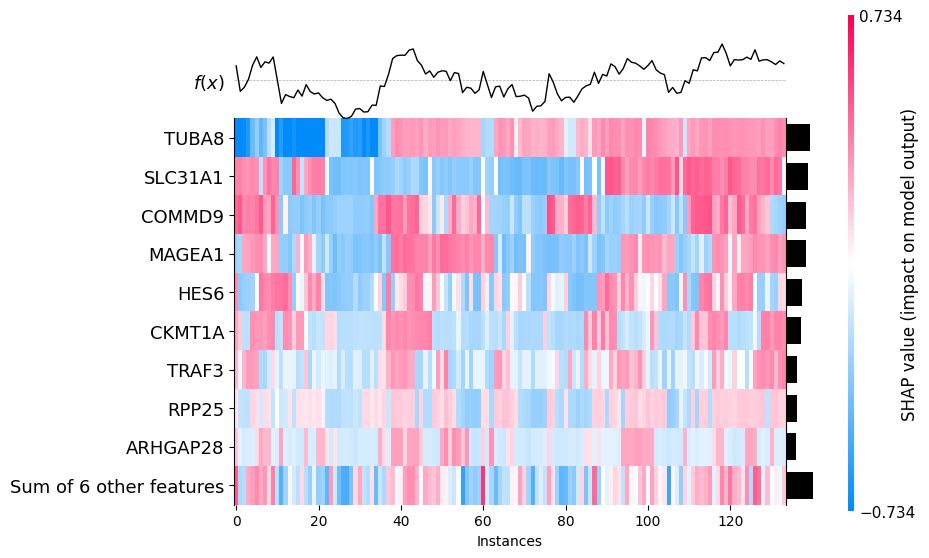

<Axes: xlabel='Instances'>

In [ ]:
shap.plots.heatmap(sv_all)

### Violin plot

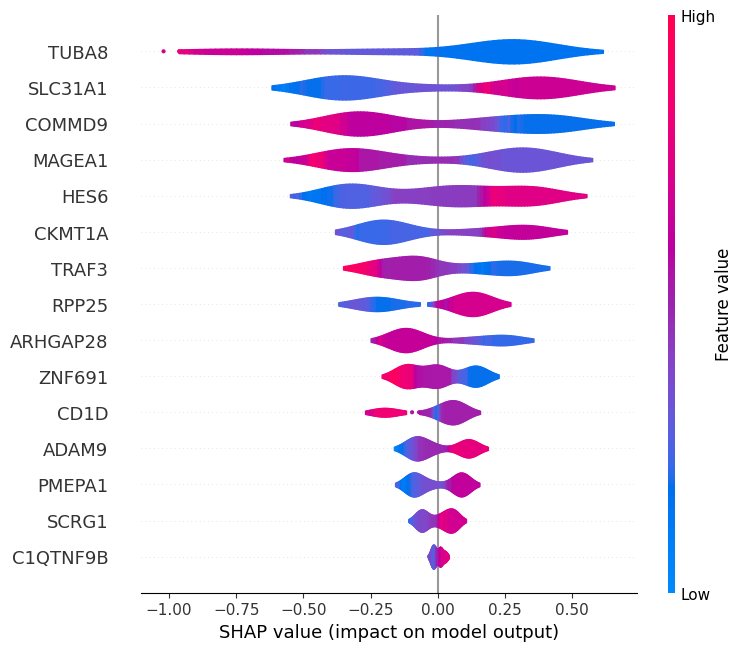

In [ ]:
shap.plots.violin(sv_all)